# Proyek Analisis Data: Bike Sharing Dataset
- **Nama: Hikmal Arya Dwitama**
- **Email: cdcc200d6y1003@student.devacademy.id**
- **ID Dicoding: CDCC200D6Y1003**

# Pertanyaan Bisnis
1. Bagaimana hubungan antara jumlah penyewaan sepeda (cnt) dengan suhu (temp) selama periode 2011–2012?
2. Bagaimana pengaruh kelembaban udara (hum) terhadap jumlah penyewaan sepeda (cnt) selama periode 2011–2012?
3. Bagaimana tren jumlah penyewaan sepeda (cnt) berdasarkan waktu (dteday) dari Januari 2011 hingga Desember 2012?
4. Bagaimana perbedaan jumlah penyewaan sepeda (cnt) berdasarkan hari kerja (workingday) selama periode 2011–2012?
5. Bagaimana perbedaan jumlah penyewaan sepeda (cnt) berdasarkan musim (season) selama periode 2011–2012?

In [24]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set(style="whitegrid")

# Data Wrangling

### Gathering Data

In [25]:
# Load dataset
df = pd.read_csv("data/day.csv")

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Dataset berisi data penyewaan sepeda harian dengan variabel waktu, cuaca, dan jumlah penyewaan (cnt). Beberapa variabel kategori masih berupa angka sehingga perlu mapping pada tahap cleaning.

### Assessing dataset

In [26]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [27]:
# Statistik deskriptif
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [28]:
# Cek Missing value
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [29]:
# Cek Data Duplikat
df.duplicated().sum()

np.int64(0)

In [30]:
# Cek nilai unik pada variabel kategorik
df["season"].value_counts()

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64

In [31]:
df["workingday"].value_counts()

workingday
1    500
0    231
Name: count, dtype: int64

Dataset terdiri dari 731 data tanpa missing value dan duplikasi, sehingga kualitas data sudah baik. Variabel dteday masih bertipe object dan perlu dikonversi ke datetime. Nilai cnt memiliki rentang yang cukup besar, menunjukkan adanya variasi penyewaan antar hari.

### Data Cleaning

In [32]:
# Konversi tipe data tanggal
df["dteday"] = pd.to_datetime(df["dteday"])

In [33]:
# Mapping season
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

df["season"] = df["season"].map(season_map)

# Cek Hasil Mapping
df["season"].unique()

array(['Spring', 'Summer', 'Fall', 'Winter'], dtype=object)

In [34]:
# Mapping workingday
df["workingday"] = df["workingday"].map({
    0: "Holiday",
    1: "Working Day"
})

# Cek Hasil Mapping
df["workingday"].unique()

array(['Holiday', 'Working Day'], dtype=object)

In [35]:
# Cek ulang data setelah cleaning
print("Missing values:\n", df.isna().sum())
print("\nJumlah duplikasi:", df.duplicated().sum())

Missing values:
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah duplikasi: 0


In [36]:
# Statistik Deskriptif Data Setelah Cleaning
df.describe()

,instant,dteday,yr,mnth,holiday,weekday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,0.028728,2.997264,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,0.000000,5.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,1.000000,6.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,0.167155,2.004787,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [37]:
# Simpan dataset hasil cleaning
df.to_csv("dashboard/main_data.csv", index=False)
print("Dataset berhasil disimpan ke dashboard/main_data.csv")

Dataset berhasil disimpan ke dashboard/main_data.csv


Tipe data dteday berhasil dikonversi menjadi datetime, dan variabel season serta workingday telah diubah menjadi kategori yang lebih mudah dipahami. Setelah proses cleaning, tidak ditemukan missing values maupun duplikasi, sehingga data sudah bersih dan siap untuk dianalisis lebih lanjut.

# Exploratory Data Analysis (EDA)

### Data Overview

In [38]:
# Menampilkan sampel data
df.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
260,261,2011-09-18,Fall,0,9,0,0,Holiday,1,0.507500,0.490537,0.695000,0.178483,1353,2921,4274
99,100,2011-04-10,Summer,0,4,0,0,Holiday,2,0.426667,0.426737,0.857500,0.146767,1188,1707,2895
459,460,2012-04-04,Summer,1,4,0,3,Working Day,1,0.541667,0.533450,0.469583,0.180975,1058,5378,6436
42,43,2011-02-12,Spring,0,2,0,6,Holiday,1,0.222500,0.232954,0.544167,0.203367,288,1184,1472
699,700,2012-11-30,Winter,1,11,0,5,Working Day,1,0.298333,0.323867,0.649583,0.058471,362,5306,5668


In [39]:
# Rentang Waktu yang Digunakan
print("Tanggal awal:", df["dteday"].min())
print("Tanggal akhir:", df["dteday"].max())

Tanggal awal: 2011-01-01 00:00:00
Tanggal akhir: 2012-12-31 00:00:00


### Univariate Analysis

Analisis univariat dilakukan untuk memahami distribusi masing-masing variabel secara individual, khususnya variabel numerik yang digunakan dalam analisis.

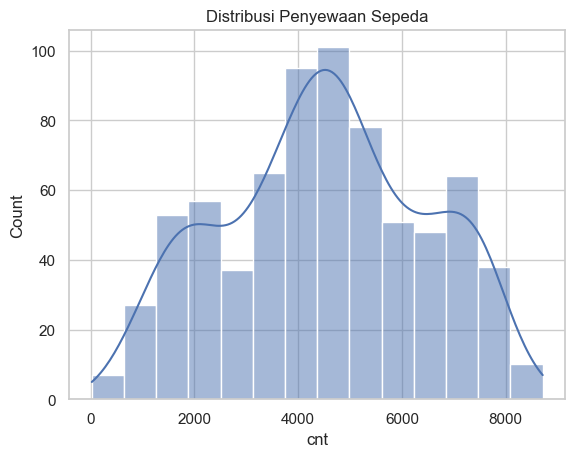

In [40]:
# Histogram Penyewaan Sepeda (cnt)
sns.histplot(df["cnt"], kde=True)
plt.title("Distribusi Penyewaan Sepeda")
plt.show()

Distribusi cnt cenderung mendekati normal dengan mayoritas nilai berada pada tingkat penyewaan menengah. Hal ini menunjukkan bahwa permintaan penyewaan relatif stabil dengan variasi antar hari.

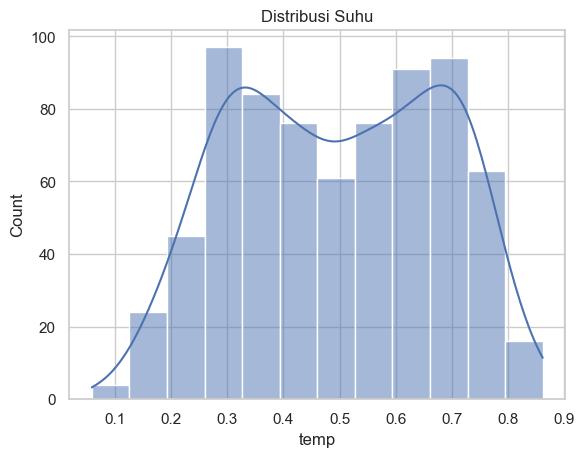

In [41]:
# Histogram Suhu (temp)
sns.histplot(df["temp"], kde=True)
plt.title("Distribusi Suhu")
plt.show()

Distribusi temp relatif merata dengan dominasi pada suhu sedang. Hal ini mengindikasikan bahwa variasi suhu cukup luas dan berpotensi menjadi salah satu faktor penting yang memengaruhi jumlah penyewaan sepeda.

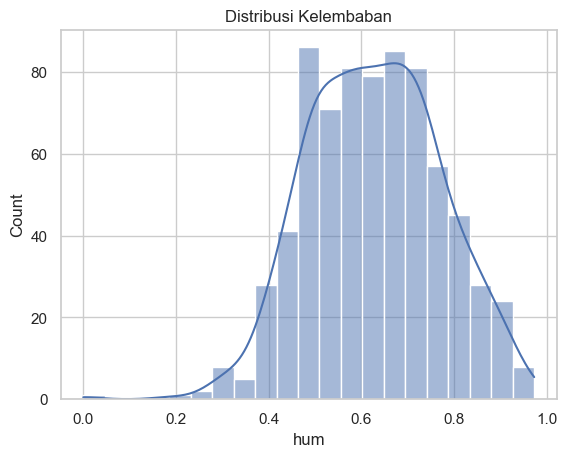

In [42]:
# Histogram Kelembaban (hum)
sns.histplot(df["hum"], kde=True)
plt.title("Distribusi Kelembaban")
plt.show()

Distribusi hum didominasi oleh nilai kelembaban sedang hingga tinggi. Hal ini menunjukkan bahwa sebagian besar hari memiliki tingkat kelembaban yang cukup tinggi, yang berpotensi memengaruhi variasi jumlah penyewaan sepeda.

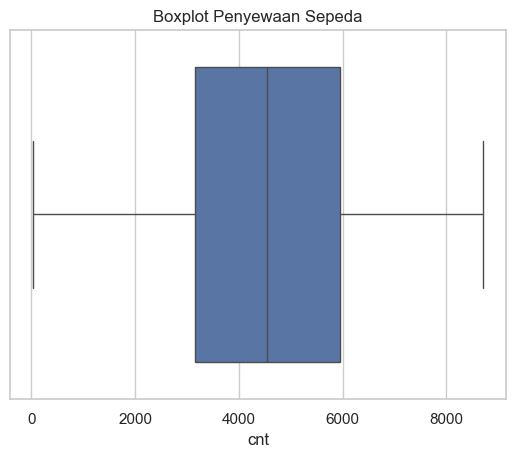

In [43]:
# Boxplot Penyewaan Sepeda (cnt)
sns.boxplot(x=df["cnt"])
plt.title("Boxplot Penyewaan Sepeda")
plt.show()

Distribusi cnt menunjukkan variasi yang cukup besar dengan median berada di tengah rentang data. Hal ini menandakan adanya fluktuasi jumlah penyewaan antar hari, namun tidak terlihat outlier ekstrem yang signifikan.

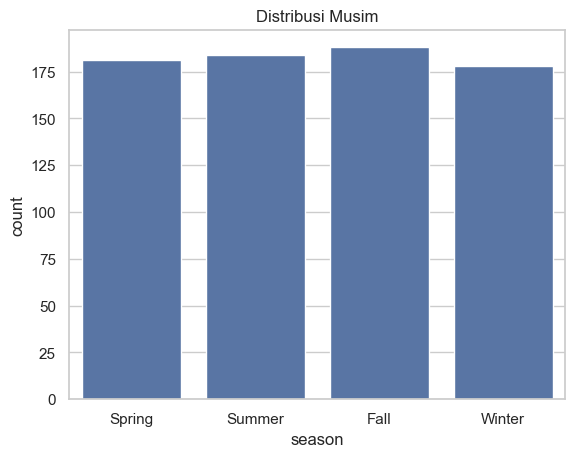

In [44]:
# Distribusi Musim (season)
sns.countplot(x="season", data=df)
plt.title("Distribusi Musim")
plt.show()

Distribusi data pada setiap musim relatif seimbang, sehingga tidak terdapat bias jumlah data pada musim tertentu. Hal ini memungkinkan analisis perbandingan antar musim dilakukan secara lebih adil dan representatif.

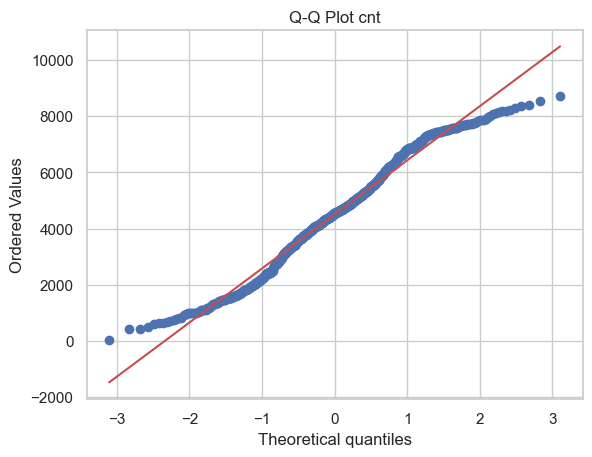

In [45]:
# Skewness & Q-Q Plot (cnt)
stats.probplot(df["cnt"], dist="norm", plot=plt)
plt.title("Q-Q Plot cnt")
plt.show()

Titik-titik pada Q-Q plot sebagian besar mengikuti garis diagonal, yang menunjukkan bahwa distribusi cnt mendekati normal. Namun, terdapat sedikit penyimpangan pada bagian ekor, yang menandakan adanya variasi nilai ekstrem meskipun tidak signifikan.

### Multivariate Analysis

Analisis multivariat dilakukan untuk memahami hubungan antar variabel, khususnya pengaruh suhu (temp) dan kelembaban (hum) terhadap jumlah penyewaan sepeda (cnt).

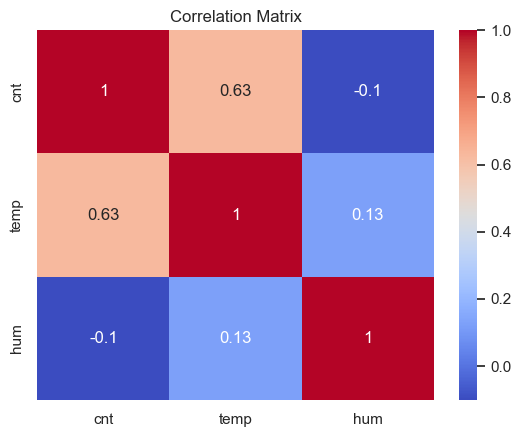

In [46]:
# Correlation Matrix (cnt, temp, hum)
cols = ["cnt","temp","hum"]

sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Terdapat korelasi positif yang cukup kuat antara temp dan cnt (≈0.63), yang menunjukkan bahwa kenaikan suhu cenderung diikuti peningkatan jumlah penyewaan. Sementara itu, hum memiliki korelasi negatif yang lemah terhadap cnt, sehingga pengaruhnya relatif kecil.

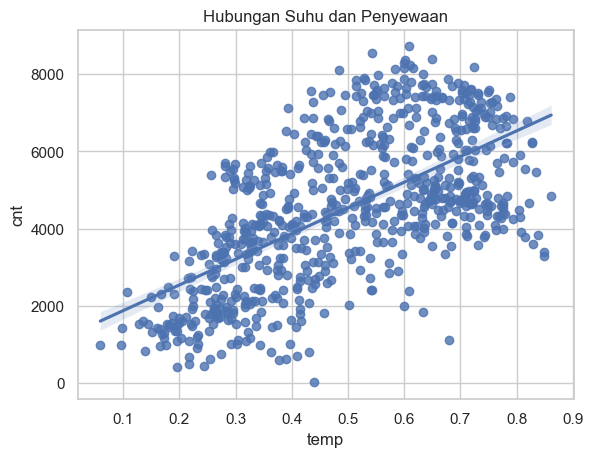

In [47]:
# Hubungan Suhu dan Penyewaan sepeda (temp vs cnt)
sns.regplot(x="temp", y="cnt", data=df)
plt.title("Hubungan Suhu dan Penyewaan")
plt.show()

Scatter plot menunjukkan hubungan positif antara suhu dan jumlah penyewaan. Semakin tinggi suhu, semakin meningkat jumlah penyewaan sepeda, meskipun terdapat variasi data pada setiap tingkat suhu.

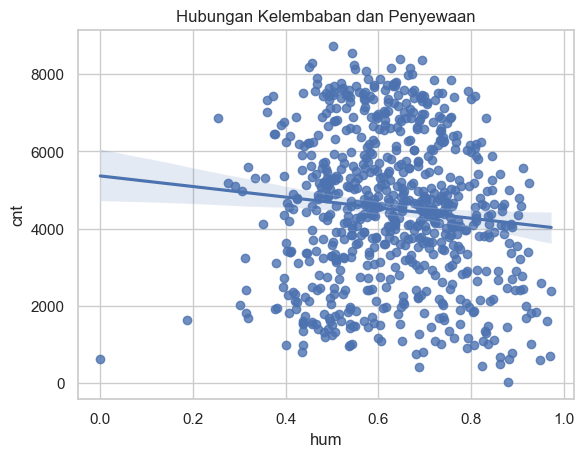

In [48]:
# Hubungan Kelembaban dan Penyewaan (hum vs cnt)
sns.regplot(x="hum", y="cnt", data=df)
plt.title("Hubungan Kelembaban dan Penyewaan")
plt.show()

Scatter plot menunjukkan hubungan negatif yang lemah antara kelembaban dan jumlah penyewaan. Peningkatan kelembaban cenderung diikuti penurunan jumlah penyewaan, namun hubungan ini tidak terlalu kuat karena penyebaran data cukup luas.

### Numerical Analysis

Analisis numerik dilakukan untuk memahami karakteristik statistik data, termasuk distribusi, variasi, dan perbedaan antar kelompok.

In [49]:
# Analisis Percentile (cnt)
df["cnt"].describe(percentiles=[0.05, 0.1, 0.9, 0.95])

count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
5%       1331.000000
10%      1746.000000
50%      4548.000000
90%      7290.000000
95%      7576.000000
max      8714.000000
Name: cnt, dtype: float64

Nilai mean (4504.34) dan median (4548) yang berdekatan menunjukkan distribusi yang cukup simetris. Rentang antara persentil 10% (1746) dan 90% (7290) menunjukkan variasi penyewaan yang cukup besar antar hari, yang mengindikasikan adanya fluktuasi permintaan.

In [50]:
# Variasi Berdasarkan Musim
df.groupby("season")["cnt"].std()

season
Fall      1459.800381
Spring    1399.942119
Summer    1695.977235
Winter    1699.615261
Name: cnt, dtype: float64

Standar deviasi tertinggi terdapat pada musim Summer dan Winter, yang menunjukkan variasi penyewaan lebih besar pada kedua musim tersebut. Hal ini mengindikasikan bahwa permintaan pada musim tersebut cenderung lebih fluktuatif dibandingkan musim lainnya.

In [51]:
# Variasi Berdasarkan Hari Kerja
print("Standar Deviasi cnt berdasarkan Workingday")

df.groupby("workingday")["cnt"].std()

Standar Deviasi cnt berdasarkan Workingday


workingday
Holiday        2052.141245
Working Day    1878.415583
Name: cnt, dtype: float64

Standar deviasi pada hari libur lebih tinggi dibandingkan hari kerja, yang menunjukkan bahwa penyewaan sepeda pada hari libur cenderung lebih bervariasi. Hal ini mengindikasikan pola penggunaan yang lebih tidak konsisten dibandingkan hari kerja.

### Time Series Analysis

Analisis time series dilakukan untuk melihat pola perubahan jumlah penyewaan sepeda (cnt) dari waktu ke waktu selama periode 2011–2012.

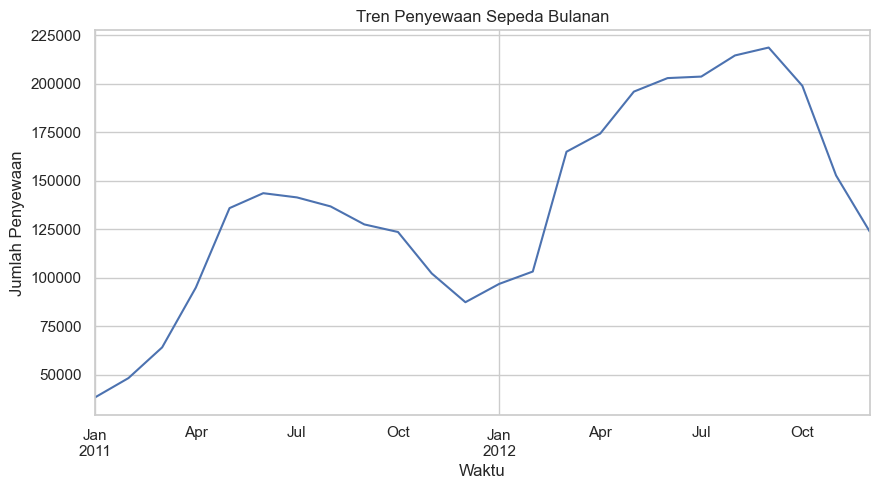

In [52]:
# Tren Penyewaan Sepeda
monthly = df.set_index("dteday").resample("ME")["cnt"].sum()

plt.figure(figsize=(10,5))
monthly.plot()

plt.title("Tren Penyewaan Sepeda Bulanan")
plt.xlabel("Waktu")
plt.ylabel("Jumlah Penyewaan")

plt.show()

Jumlah penyewaan sepeda menunjukkan pola musiman yang jelas, dengan peningkatan dari awal tahun hingga pertengahan tahun, kemudian menurun menjelang akhir tahun. Selain itu, terlihat bahwa tingkat penyewaan pada tahun 2012 secara umum lebih tinggi dibandingkan tahun 2011, yang mengindikasikan adanya peningkatan permintaan dari waktu ke waktu.

### Categorical Analysis

Analisis kategorikal dilakukan untuk melihat perbedaan jumlah penyewaan sepeda (cnt) berdasarkan variabel kategori, yaitu workingday dan season.

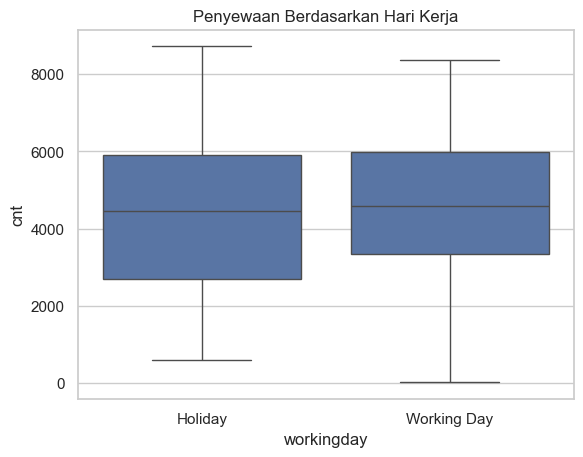

In [53]:
# Penyewaan Sepeda Berdasarkan Hari Kerja (workingday)
sns.boxplot(x="workingday", y="cnt", data=df)
plt.title("Penyewaan Berdasarkan Hari Kerja")
plt.show()

Distribusi penyewaan pada hari kerja dan hari libur terlihat relatif mirip, dengan median yang tidak jauh berbeda. Hal ini menunjukkan bahwa perbedaan jumlah penyewaan antara hari kerja dan hari libur tidak terlalu signifikan.

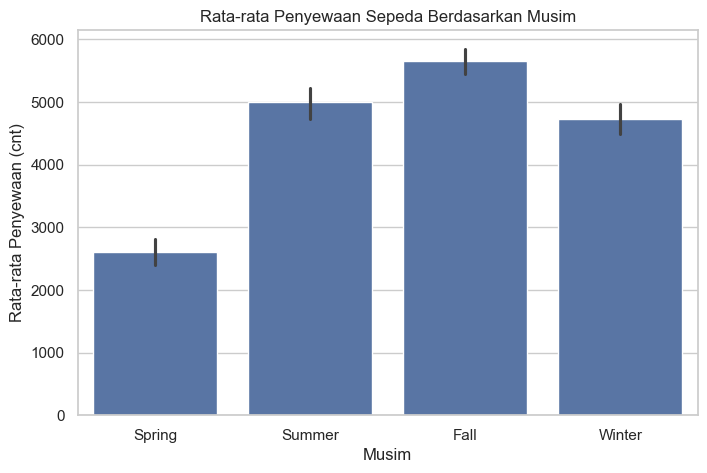

In [54]:
# Penyewaan Sepeda Berdasarkan Musim (season)
plt.figure(figsize=(8,5))

sns.barplot(
    x="season",
    y="cnt",
    data=df,
    order=["Spring","Summer","Fall","Winter"]
)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Penyewaan (cnt)")

plt.show()

Rata-rata penyewaan sepeda tertinggi terjadi pada musim Fall, diikuti Summer dan Winter, sedangkan Spring memiliki rata-rata terendah. Hal ini menunjukkan bahwa musim memiliki pengaruh terhadap jumlah penyewaan, di mana kondisi tertentu cenderung meningkatkan permintaan.

# Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana hubungan antara jumlah penyewaan sepeda (cnt) dengan suhu (temp) selama periode 2011–2012?

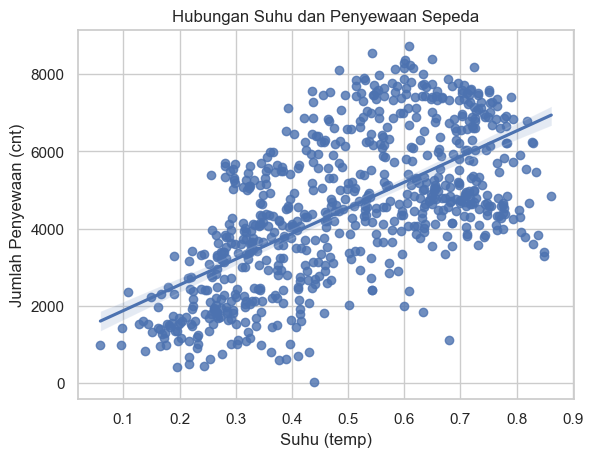

In [55]:
# Hubungan Suhu dan Penyewaan Sepeda
sns.regplot(x="temp", y="cnt", data=df)
plt.title("Hubungan Suhu dan Penyewaan Sepeda")
plt.xlabel("Suhu (temp)")
plt.ylabel("Jumlah Penyewaan (cnt)")
plt.show()

Berdasarkan scatter plot antara temp dan cnt, terlihat pola hubungan yang jelas positif. Titik-titik data membentuk tren naik, yang diperkuat oleh garis regresi yang menanjak.

Pada suhu rendah, jumlah penyewaan cenderung berada pada level rendah. Seiring meningkatnya suhu, jumlah penyewaan juga meningkat secara konsisten hingga mencapai nilai yang lebih tinggi.

Meskipun terdapat penyebaran data (variasi) pada setiap tingkat suhu, pola umum tetap menunjukkan bahwa suhu memiliki pengaruh yang cukup kuat terhadap peningkatan jumlah penyewaan sepeda.

### Pertanyaan 2: Bagaimana pengaruh kelembaban udara (hum) terhadap jumlah penyewaan sepeda (cnt) selama periode 2011–2012?

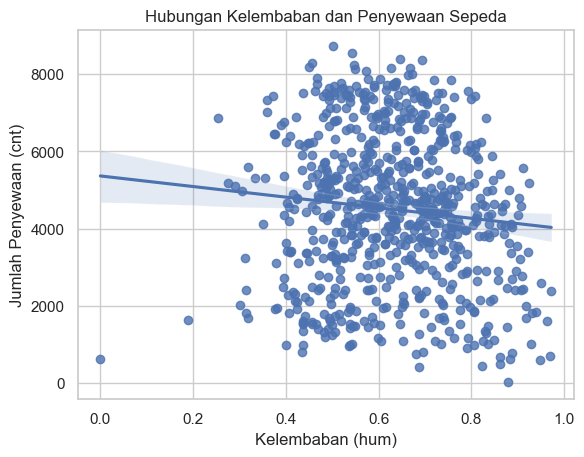

In [56]:
# Hubungan Kelembaban dan Penyewaan Sepeda
sns.regplot(x="hum", y="cnt", data=df)
plt.title("Hubungan Kelembaban dan Penyewaan Sepeda")
plt.xlabel("Kelembaban (hum)")
plt.ylabel("Jumlah Penyewaan (cnt)")
plt.show()

Berdasarkan scatter plot antara hum dan cnt, terlihat bahwa hubungan keduanya cenderung negatif, yang ditunjukkan oleh garis regresi yang menurun. Artinya, ketika kelembaban meningkat, jumlah penyewaan sepeda cenderung menurun.

Namun, penyebaran titik data cukup luas di sepanjang grafik. Hal ini menunjukkan bahwa pada tingkat kelembaban yang sama, jumlah penyewaan bisa sangat bervariasi. Dengan kata lain, hubungan antara kelembaban dan penyewaan tidak terlalu kuat atau konsisten.

Kondisi ini mengindikasikan bahwa kelembaban memang memiliki pengaruh terhadap penyewaan sepeda, tetapi bukan faktor utama. Masih terdapat faktor lain yang lebih dominan dalam menentukan jumlah penyewaan.

### Pertanyaan 3: Bagaimana tren jumlah penyewaan sepeda (cnt) berdasarkan waktu (dteday) dari Januari 2011 hingga Desember 2012?

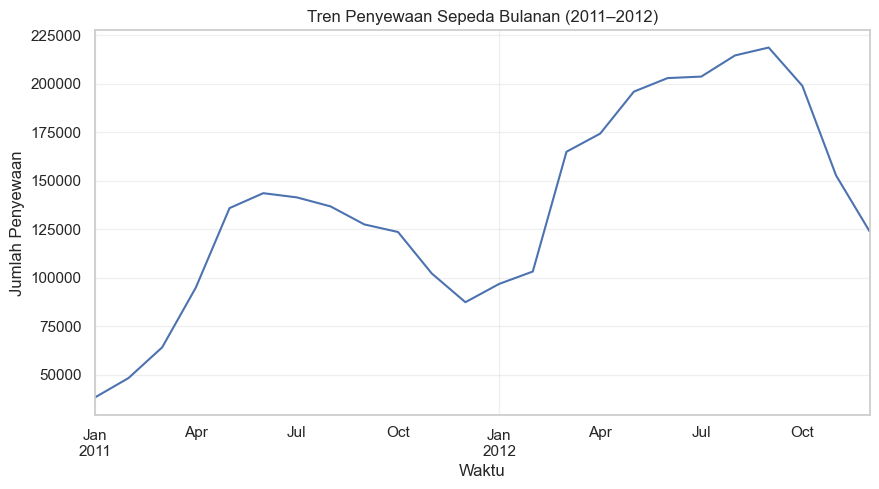

In [57]:
# Tren Penyewaan Sepeda Bulanan 2011-2012
monthly = df.set_index("dteday").resample("ME")["cnt"].sum()

plt.figure(figsize=(10,5))
monthly.plot()

plt.title("Tren Penyewaan Sepeda Bulanan (2011–2012)")
plt.xlabel("Waktu")
plt.ylabel("Jumlah Penyewaan")
plt.grid(alpha=0.3)

plt.show()

Grafik tren bulanan menunjukkan pola yang berulang setiap tahun, di mana jumlah penyewaan meningkat dari awal tahun, mencapai puncak di pertengahan tahun, dan kemudian menurun kembali menjelang akhir tahun.

Pola ini terlihat konsisten pada tahun 2011 maupun 2012, yang menandakan adanya seasonality (pola musiman) dalam penggunaan sepeda. Selain itu, terlihat bahwa nilai penyewaan pada tahun 2012 secara keseluruhan lebih tinggi dibandingkan tahun 2011.

Hal ini menunjukkan bahwa selain adanya pola musiman, terdapat juga tren peningkatan penggunaan sepeda dari waktu ke waktu.

### Pertanyaan 4: Bagaimana perbedaan jumlah penyewaan sepeda (cnt) berdasarkan hari kerja (workingday) selama periode 2011–2012?

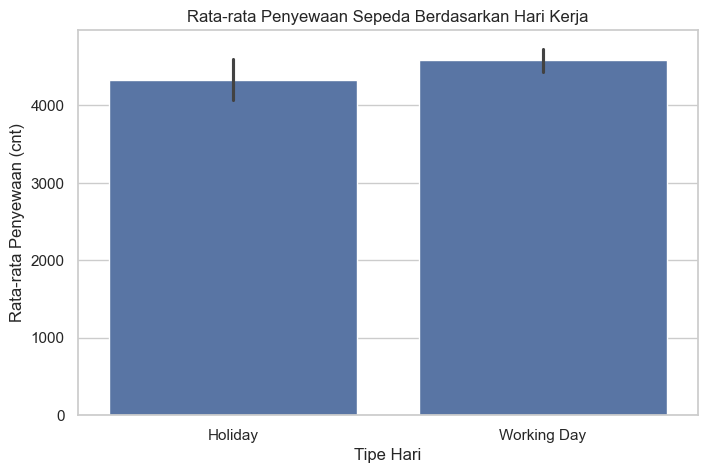

In [58]:
# Penyewaan Sepeda Berdasarkan Hari Kerja
plt.figure(figsize=(8, 5))

sns.barplot(
    x="workingday",
    y="cnt",
    data=df,
    order=["Holiday", "Working Day"]
)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Hari Kerja")
plt.xlabel("Tipe Hari")
plt.ylabel("Rata-rata Penyewaan (cnt)")
plt.show()

Berdasarkan barplot, terlihat bahwa rata-rata penyewaan pada hari kerja (Working Day) sedikit lebih tinggi dibandingkan hari libur (Holiday). Namun, selisih antara keduanya tidak terlalu besar.

Hal ini menunjukkan bahwa aktivitas penyewaan sepeda relatif stabil baik pada hari kerja maupun hari libur. Selain itu, dari analisis sebelumnya (t-test), juga diketahui bahwa perbedaan ini tidak signifikan secara statistik.

### Pertanyaan 5: Bagaimana perbedaan jumlah penyewaan sepeda (cnt) berdasarkan musim (season) selama periode 2011–2012?

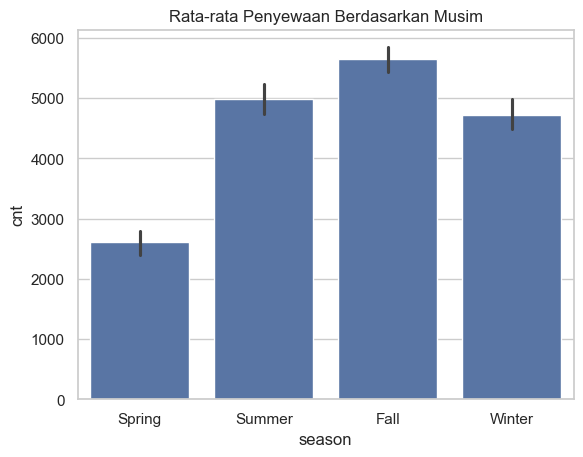

In [59]:
# Rata-rata Penyewaan Sepeda Berdasarkan Musim
sns.barplot(x="season", y="cnt", data=df)
plt.title("Rata-rata Penyewaan Berdasarkan Musim")
plt.show()

Barplot menunjukkan adanya perbedaan yang cukup jelas antara musim. Rata-rata penyewaan tertinggi terjadi pada musim Fall, diikuti oleh Summer dan Winter, sementara Spring memiliki rata-rata terendah.

Selain itu, perbedaan antar musim terlihat cukup signifikan, yang menunjukkan bahwa musim memiliki pengaruh yang nyata terhadap jumlah penyewaan sepeda.

Hal ini juga konsisten dengan pola sebelumnya, di mana periode dengan kondisi yang lebih nyaman cenderung memiliki permintaan yang lebih tinggi.

# Analisis Lanjutan (Opsional)

### Uji t-test

Uji t-test digunakan untuk mengetahui apakah terdapat perbedaan yang signifikan secara statistik antara rata-rata jumlah penyewaan sepeda pada hari kerja (workingday) dan hari libur.

In [60]:
working = df[df["workingday"] == "Working Day"]["cnt"]
holiday = df[df["workingday"] == "Holiday"]["cnt"]

t_stat, p_value = stats.ttest_ind(working, holiday, equal_var=False)
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

if p_value < 0.05:
    print("Terdapat perbedaan yang signifikan secara statistik.")
else:
    print("Tidak terdapat perbedaan yang signifikan secara statistik.")

T-statistic : 1.6014
P-value     : 0.1101
Tidak terdapat perbedaan yang signifikan secara statistik.


Hasil uji menunjukkan nilai p-value sebesar 0.1101 (> 0.05), yang berarti tidak terdapat perbedaan yang signifikan antara kedua kelompok.

Meskipun secara rata-rata terdapat sedikit perbedaan, namun perbedaan tersebut tidak cukup kuat secara statistik.

### Tren Penyewaan Sepeda Berdasarkan Tahun

Analisis ini dilakukan untuk membandingkan pola penyewaan sepeda antar tahun, serta melihat apakah terdapat peningkatan atau perubahan tren dari waktu ke waktu.

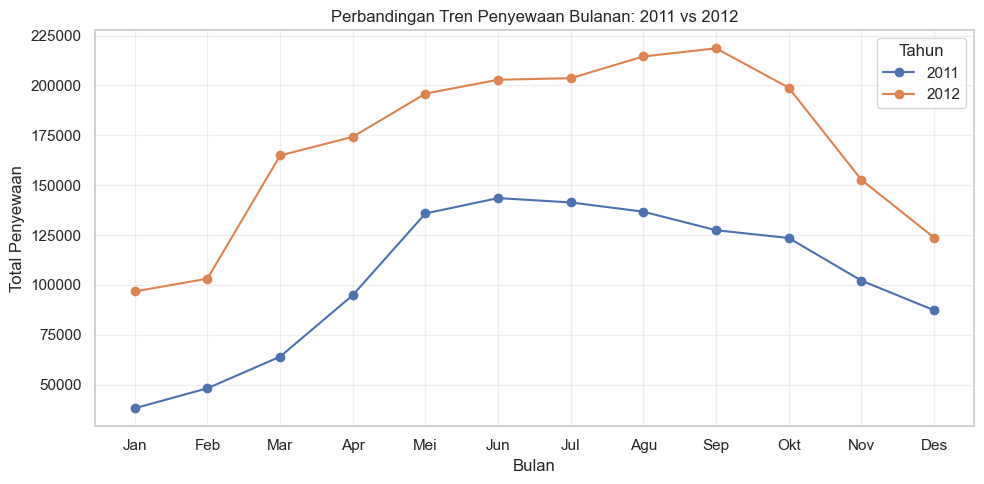

In [61]:
# Tren bulanan 2011 vs 2012
df["year"] = df["dteday"].dt.year
df["month"] = df["dteday"].dt.month

monthly_year = df.groupby(["year", "month"])["cnt"].sum().reset_index()

plt.figure(figsize=(10, 5))
for year, group in monthly_year.groupby("year"):
    plt.plot(group["month"], group["cnt"], marker="o", label=str(year))

plt.title("Perbandingan Tren Penyewaan Bulanan: 2011 vs 2012")
plt.xlabel("Bulan")
plt.ylabel("Total Penyewaan")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","Mei","Jun","Jul","Agu","Sep","Okt","Nov","Des"])
plt.legend(title="Tahun")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Grafik menunjukkan bahwa pola penyewaan pada tahun 2011 dan 2012 memiliki bentuk yang serupa, yaitu meningkat dari awal tahun hingga pertengahan tahun, kemudian menurun di akhir tahun.

Namun, secara konsisten nilai penyewaan pada tahun 2012 lebih tinggi dibandingkan 2011 di hampir semua bulan. Hal ini menunjukkan adanya peningkatan penggunaan sepeda dari tahun ke tahun.

### Binning Suhu (temp)

Analisis binning dilakukan untuk mengelompokkan suhu ke dalam beberapa kategori agar hubungan antara suhu dan jumlah penyewaan lebih mudah dipahami dan diinterpretasikan.

In [62]:
# Binning suhu menjadi 3 kategori
df["temp_category"] = pd.cut(
    df["temp"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["Dingin", "Sedang", "Panas"]
)

In [63]:
# Rata-rata penyewaan per kategori suhu
temp_summary = df.groupby("temp_category", observed=True)["cnt"].mean().reset_index()

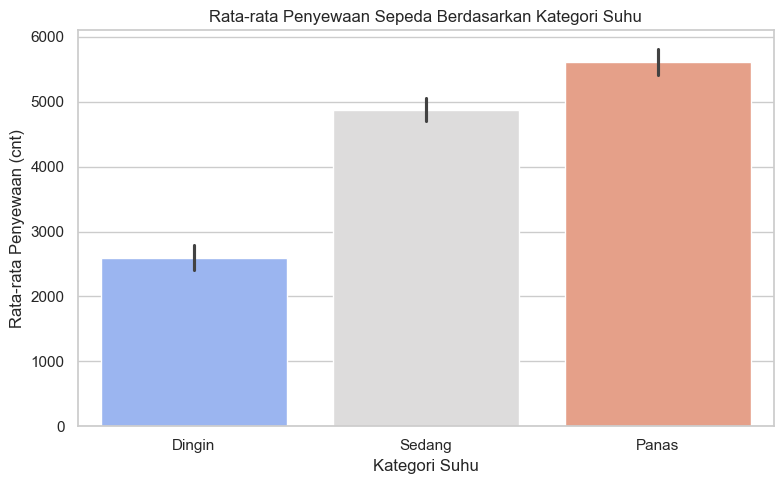

In [64]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="temp_category",
    y="cnt",
    data=df,
    order=["Dingin", "Sedang", "Panas"],
    palette="coolwarm",
    hue="temp_category",   # FIX warning
    legend=False
)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kategori Suhu")
plt.xlabel("Kategori Suhu")
plt.ylabel("Rata-rata Penyewaan (cnt)")
plt.tight_layout()
plt.show()

Berdasarkan hasil pengelompokan suhu ke dalam tiga kategori, yaitu Dingin, Sedang, dan Panas, terlihat adanya pola yang konsisten pada jumlah penyewaan sepeda. Rata-rata penyewaan pada kategori suhu dingin berada pada tingkat paling rendah, kemudian meningkat pada kategori suhu sedang, dan mencapai nilai tertinggi pada kategori suhu panas.

Pola ini menunjukkan bahwa terdapat hubungan yang cukup jelas antara suhu dan jumlah penyewaan sepeda. Semakin tinggi suhu, semakin meningkat aktivitas penyewaan. Hal ini mengindikasikan bahwa kondisi suhu yang lebih hangat cenderung mendorong masyarakat untuk melakukan aktivitas luar ruangan, termasuk menggunakan sepeda.

# Kesimpulan dan Rekomendasi

### Kesimpulan

**- Kesimpulan Pertanyaan 1:** Terdapat hubungan positif yang cukup kuat antara suhu (temp) dan jumlah penyewaan sepeda (cnt). Semakin tinggi suhu, semakin tinggi pula jumlah penyewaan. Hal ini dikonfirmasi oleh nilai korelasi positif pada correlation matrix dan garis regresi yang menanjak pada scatter plot.

**- Kesimpulan Pertanyaan 2:**
Kelembaban udara (hum) memiliki pengaruh negatif yang lemah terhadap jumlah penyewaan sepeda. Peningkatan kelembaban cenderung menurunkan jumlah penyewaan, namun penyebaran data yang luas menunjukkan bahwa kelembaban bukan faktor utama penentu permintaan sepeda.

**- Kesimpulan Pertanyaan 3:**
Tren penyewaan dari Januari 2011 hingga Desember 2012 menunjukkan pertumbuhan yang positif dengan pola musiman yang konsisten. Puncak penyewaan terjadi di pertengahan tahun, dan secara umum volume penyewaan tahun 2012 lebih tinggi dibandingkan 2011 di hampir setiap bulannya.

**- Kesimpulan Pertanyaan 4:**
Tidak terdapat perbedaan yang signifikan antara jumlah penyewaan sepeda pada hari kerja dan hari libur, baik secara visual maupun secara statistik berdasarkan hasil uji t-test (p-value > 0.05). Hal ini mengindikasikan bahwa sepeda digunakan untuk berbagai keperluan di kedua tipe hari tersebut, baik komuter maupun rekreasi.

**- Kesimpulan Pertanyaan 5:**
Musim Fall memiliki rata-rata penyewaan tertinggi, diikuti Summer dan Winter, sementara Spring memiliki rata-rata terendah. Musim merupakan faktor yang signifikan dalam menentukan pola permintaan penyewaan sepeda, yang sejalan dengan pengaruh suhu pada masing-masing musim.

### Rekomendasi

- Operator layanan bike sharing sebaiknya meningkatkan ketersediaan armada sepeda pada musim Fall dan Summer, serta pada hari-hari dengan suhu lebih hangat untuk memaksimalkan pendapatan.

- Meskipun kelembaban bukan faktor utama, operator dapat menyediakan informasi cuaca real-time kepada pengguna melalui aplikasi agar pengguna dapat merencanakan perjalanan pada hari-hari dengan kelembaban tinggi.

- Mengingat tren pertumbuhan yang positif dari 2011 ke 2012, operator dapat terus berinvestasi dalam penambahan armada dan perluasan titik penyewaan untuk mengakomodasi pertumbuhan permintaan di masa mendatang.

- Karena penyewaan di hari kerja dan hari libur tidak berbeda signifikan, operator sebaiknya menjaga ketersediaan armada yang merata setiap hari tanpa perlu membedakan alokasi berdasarkan tipe hari.